# 1D CNN Classifier for Terrain Classification with Strict LORO-CV

This notebook trains a **1D Convolutional Neural Network** directly on **raw windowed IMU signals**,
without any hand-crafted feature engineering. The CNN learns to extract relevant features from the
raw time-series automatically.

**Key design decisions:**
- Input: raw windowed signals (200 timesteps × 5 channels: ax, ay, az, gx, gz)
- No feature engineering — CNN learns representations directly
- gy (yaw rate) is excluded, consistent with all other notebooks (encodes turning, not terrain)
- Same strict 5-run LORO-CV as baselines and MLP for directly comparable results

**Evaluation protocol (identical to 07_baselines.ipynb and 09_mlp.ipynb):**
- Leave-One-Run-Out Cross-Validation (LORO-CV): train on 4 runs, test on 1
- Train/test split at the **run level** — no window from the test run ever appears in training
- Validation split (15%) carved from training fold only (never overlaps with test run)
- Early stopping on validation loss to prevent overfitting
- Segment-aware windowing already applied (windows never cross temporal gaps)

**Data splits:** 5-run LORO-CV (run 3 split into part A and part B at temporal midpoint)

In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, TensorDataset

# Configure plotting
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

# ============================================================================
# ENVIRONMENT SUMMARY
# ============================================================================
print("=" * 80)
print("ENVIRONMENT SUMMARY - 1D CNN Classifier for Terrain Classification")
print("=" * 80)
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Python version: {sys.version}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print("=" * 80)

# Project bootstrap: ensure src/ is in path for imports
cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / "src").exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.windowing import create_windows

ENVIRONMENT SUMMARY - 1D CNN Classifier for Terrain Classification
PyTorch version: 2.11.0
Device: cpu
CUDA available: False
Python version: 3.11.14 | packaged by conda-forge | (main, Jan 27 2026, 00:01:01) [Clang 19.1.7 ]
NumPy version: 2.4.2
Pandas version: 3.0.0


## Cell 1: Configuration

In [2]:
# ============================================================================
# DATA CONFIGURATION
# ============================================================================
FILTERED_PATH = PROJECT_ROOT / "data" / "interim" / "filtered" / "filtered_dataset.csv"
RAW_WIN_PATH  = PROJECT_ROOT / "data" / "processed" / "raw_windows_cnn.parquet"
RESULTS_DIR   = PROJECT_ROOT / "results" / "cnn"
REPORTS_DIR   = PROJECT_ROOT / "reports" / "models"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================================
# SIGNAL CONFIGURATION
# ============================================================================
# 5 channels: ax, ay, az (accelerometer) + gx, gz (gyro pitch + roll)
# gy (yaw rate) is excluded — consistent with feature engineering in all other notebooks,
# because yaw encodes the robot's turning direction, not terrain properties.
SIGNAL_COLS = ["ax", "ay", "az", "gx", "gz"]
N_CHANNELS  = len(SIGNAL_COLS)   # 5
WINDOW_SIZE = 200                 # 2 s at 100 Hz — matches notebook 05_windowing.ipynb
STEP_SIZE   = 100                 # 50% overlap

# ============================================================================
# LORO-CV CONFIGURATION
# ============================================================================
LABEL_COL = "label"
RUN_COL   = "run_id"
RUN3_ID   = "log_20260309_141435.414"   # Run 3 is split into partA / partB

# Canonical label order (same as 07_baselines.ipynb and 09_mlp.ipynb)
LABEL_ORDER = [
    "cobblestone",
    "dry_dirt_track",
    "grass",
    "muddy_dirt_track",
    "smooth_terrain",
]

# After the 5-run split (run 3 → partA + partB), no test fold has missing classes.
# This map is intentionally empty; the LORO-CV loop enforces strict matching.
KNOWN_DEGENERATE = {}

# Speed regime confounds for cobblestone (same notes as MLP notebook)
KNOWN_CONFOUNDED = {
    "log_20260309_141435.414_partB": {
        "cobblestone": "train=run4 only, test=partB (same session, consistent speed)",
    },
    "log_20260326_120021.508": {
        "cobblestone": "train=partB only, test=run4 (different session)",
    },
}

# ============================================================================
# CNN ARCHITECTURE PARAMETERS
# ============================================================================
# Block structure: Conv1d → BN → ReLU → MaxPool(2)
# Block 1: 5  → 32  channels, kernel 7  → (200 → 100 timesteps)
# Block 2: 32 → 64  channels, kernel 5  → (100 →  50 timesteps)
# Block 3: 64 → 128 channels, kernel 3  → ( 50 →  25 timesteps)
# Head:    AdaptiveAvgPool(1) → flatten → FC(128→64) → ReLU → Dropout → FC(64→C)
DROPOUT_RATE = 0.3

# ============================================================================
# TRAINING PARAMETERS
# ============================================================================
LEARNING_RATE           = 1e-3    # Adam optimizer initial learning rate
BATCH_SIZE              = 64      # Mini-batch size per gradient update
MAX_EPOCHS              = 200     # Maximum training epochs (early stopping may stop earlier)
EARLY_STOPPING_PATIENCE = 20      # Stop if validation loss doesn't improve for N epochs
VAL_SPLIT               = 0.15   # Stratified validation split: 15% of training fold
WEIGHT_DECAY            = 1e-4   # L2 regularisation coefficient
USE_LR_SCHEDULER        = True    # Enable CosineAnnealingLR to decay LR over training
USE_CLASS_WEIGHTS       = True    # Weight CrossEntropyLoss by inverse class frequency

# ============================================================================
# REPRODUCIBILITY
# ============================================================================
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_STATE)

print("\n" + "=" * 80)
print("CONFIGURATION SUMMARY")
print("=" * 80)
print(f"Input shape per window: ({N_CHANNELS}, {WINDOW_SIZE})  [channels × timesteps]")
print(f"Signal channels: {SIGNAL_COLS}")
print(f"Window size: {WINDOW_SIZE} samples ({WINDOW_SIZE / 100:.1f} s at 100 Hz)")
print(f"Step size: {STEP_SIZE} samples (50% overlap)")
print(f"\nCNN architecture: 3 × Conv1d blocks → AdaptiveAvgPool → FC head")
print(f"  Dropout rate: {DROPOUT_RATE}")
print(f"\nTraining:")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Max epochs: {MAX_EPOCHS}")
print(f"  Early stopping patience: {EARLY_STOPPING_PATIENCE}")
print(f"  Validation split: {VAL_SPLIT * 100:.1f}% stratified")
print(f"  Weight decay (L2): {WEIGHT_DECAY}")
print(f"  LR scheduler (CosineAnnealing): {USE_LR_SCHEDULER}")
print(f"  Class-weighted loss: {USE_CLASS_WEIGHTS}")
print("=" * 80 + "\n")


CONFIGURATION SUMMARY
Input shape per window: (5, 200)  [channels × timesteps]
Signal channels: ['ax', 'ay', 'az', 'gx', 'gz']
Window size: 200 samples (2.0 s at 100 Hz)
Step size: 100 samples (50% overlap)

CNN architecture: 3 × Conv1d blocks → AdaptiveAvgPool → FC head
  Dropout rate: 0.3

Training:
  Learning rate: 0.001
  Batch size: 64
  Max epochs: 200
  Early stopping patience: 20
  Validation split: 15.0% stratified
  Weight decay (L2): 0.0001
  LR scheduler (CosineAnnealing): True
  Class-weighted loss: True



## Cell 2: Load / Build Raw Windows (Cached)

Raw signal windows are built once from `filtered_dataset.csv` using `create_windows(include_series=True)`
and cached as a Parquet file. On subsequent runs the cache is loaded directly.

The partA/partB split for run 3 is applied **after** windowing, using the median `t_start` of run-3
windows as the temporal boundary — exactly the same logic used in `07a_dataset_A_3class_baseline.ipynb`
and `09_mlp.ipynb`.

In [3]:
if RAW_WIN_PATH.exists():
    print(f"Loading cached raw windows from: {RAW_WIN_PATH}")
    win_df = pd.read_parquet(RAW_WIN_PATH)
else:
    print(f"Building raw windows from: {FILTERED_PATH}")
    if not FILTERED_PATH.exists():
        raise FileNotFoundError(f"Missing filtered dataset: {FILTERED_PATH}")

    raw = pd.read_csv(FILTERED_PATH)
    print(f"  Loaded filtered dataset: {raw.shape[0]:,} rows × {raw.shape[1]} columns")

    win_df = create_windows(
        raw,
        feature_cols=SIGNAL_COLS,
        window_size=WINDOW_SIZE,
        step_size=STEP_SIZE,
        include_series=True,
    )
    print(f"  Windows created: {len(win_df):,}")

    # Apply run-3 partA/partB temporal split
    # This mirrors 07a_dataset_A_3class_baseline.ipynb and 09_mlp.ipynb exactly.
    run3_windows = win_df[win_df[RUN_COL] == RUN3_ID]
    if run3_windows.empty:
        raise ValueError(f"Run '{RUN3_ID}' not found in windowed data. Check FILTERED_PATH.")

    run3_mid = run3_windows["t_start"].median()
    win_df.loc[(win_df[RUN_COL] == RUN3_ID) & (win_df["t_start"] <= run3_mid), RUN_COL] = f"{RUN3_ID}_partA"
    win_df.loc[(win_df[RUN_COL] == RUN3_ID) & (win_df["t_start"] >  run3_mid), RUN_COL] = f"{RUN3_ID}_partB"
    print(f"  Run 3 split at t_start median = {run3_mid:.2f} s")

    win_df.to_parquet(RAW_WIN_PATH, index=False)
    print(f"  Saved cache: {RAW_WIN_PATH}")

# ============================================================================
# VALIDATION
# ============================================================================
missing_cols = [c for c in [RUN_COL, LABEL_COL] if c not in win_df.columns]
if missing_cols:
    raise KeyError(f"Missing required columns in win_df: {missing_cols}")

series_cols = [f"{c}__series" for c in SIGNAL_COLS]
missing_series = [c for c in series_cols if c not in win_df.columns]
if missing_series:
    raise KeyError(f"Missing series columns: {missing_series}. Delete cache and re-run.")

labels_found = sorted(win_df[LABEL_COL].astype(str).unique().tolist())
if set(labels_found) != set(LABEL_ORDER):
    raise ValueError(
        f"Label mismatch. Expected: {sorted(LABEL_ORDER)} | Found: {labels_found}"
    )

run_ids = sorted(win_df[RUN_COL].astype(str).unique().tolist())
if len(run_ids) < 2:
    raise ValueError("LORO-CV requires at least two unique runs.")

print(f"\nWindows loaded: {len(win_df):,} × {len(win_df.columns)} columns")
print(f"Runs ({len(run_ids)}): {run_ids}")
print(f"Classes: {LABEL_ORDER}")
print(f"\nLabel distribution:")
print(win_df[LABEL_COL].value_counts().reindex(LABEL_ORDER).fillna(0).astype(int).to_string())
print(f"\nWindows per run:")
print(win_df[RUN_COL].value_counts().sort_index().to_string())

Building raw windows from: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/data/interim/filtered/filtered_dataset.csv
  Loaded filtered dataset: 298,004 rows × 14 columns
  Windows created: 2,346
  Run 3 split at t_start median = 1253.73 s
  Saved cache: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/data/processed/raw_windows_cnn.parquet

Windows loaded: 2,346 × 13 columns
Runs (5): ['log_20260223_142511.490', 'log_20260226_102148.990', 'log_20260309_141435.414_partA', 'log_20260309_141435.414_partB', 'log_20260326_120021.508']
Classes: ['cobblestone', 'dry_dirt_track', 'grass', 'muddy_dirt_track', 'smooth_terrain']

Label distribution:
label
cobblestone         355
dry_dirt_track      652
grass               488
muddy_dirt_track    145
smooth_terrain      706

Windows per run:
run_id
log_20260223_142511.490          293
log_20260226_102148.990          145
log_20260309_141435.414_partA    664
log_20260309_141435.414_p

## Cell 3: CNN Architecture

```
Input: (batch, 5, 200)   — 5 channels, 200 timesteps
  ↓ Conv1d(5→32,  k=7, p=3) → BN → ReLU → MaxPool(2)   → (batch, 32,  100)
  ↓ Conv1d(32→64, k=5, p=2) → BN → ReLU → MaxPool(2)   → (batch, 64,   50)
  ↓ Conv1d(64→128,k=3, p=1) → BN → ReLU → MaxPool(2)   → (batch, 128,  25)
  ↓ AdaptiveAvgPool1d(1) → flatten                       → (batch, 128)
  ↓ Linear(128→64) → ReLU → Dropout(0.3)
  ↓ Linear(64→C)                                         → (batch, C)  logits
```

- **Increasing filter depth** (32→64→128): captures local patterns first, then compound features.
- **Decreasing kernel size** (7→5→3): coarse-to-fine temporal receptive field.
- **AdaptiveAvgPool**: collapses the temporal dimension to a fixed-size representation regardless
  of input length, making the head architecture independent of `WINDOW_SIZE`.
- **No normalisation of input channels**: the CNN handles scale differences across sensors directly.
  Class-weighted loss compensates for label imbalance.

In [4]:
class TerrainCNN1D(nn.Module):
    """
    1D Convolutional Neural Network for terrain classification from raw IMU windows.

    Architecture:
        3 convolutional blocks (Conv1d → BN → ReLU → MaxPool),
        followed by AdaptiveAvgPool and a 2-layer FC head.

    Args:
        in_channels:  Number of input sensor channels (default 5: ax,ay,az,gx,gz).
        num_classes:  Number of terrain classes.
        dropout_rate: Dropout probability in the FC head.
    """

    def __init__(
        self,
        in_channels: int = 5,
        num_classes: int = 5,
        dropout_rate: float = 0.3,
    ):
        super().__init__()

        self.in_channels = in_channels
        self.num_classes = num_classes
        self.dropout_rate = dropout_rate

        # ------------------------------------------------------------------ #
        # Convolutional backbone                                               #
        # ------------------------------------------------------------------ #
        # Block 1: coarse temporal features, large receptive field (k=7)
        self.block1 = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),  # 200 → 100
        )

        # Block 2: mid-level features
        self.block2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),  # 100 → 50
        )

        # Block 3: fine-grained features
        self.block3 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),  # 50 → 25
        )

        # Global average pooling: (batch, 128, 25) → (batch, 128, 1) → (batch, 128)
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        # ------------------------------------------------------------------ #
        # Fully connected head                                                 #
        # ------------------------------------------------------------------ #
        self.head = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(64, num_classes),  # raw logits — no softmax
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (batch, in_channels, window_size) — raw IMU signal windows

        Returns:
            logits: (batch, num_classes) — raw class scores (no softmax)
        """
        x = self.block1(x)           # (B, 32,  100)
        x = self.block2(x)           # (B, 64,   50)
        x = self.block3(x)           # (B, 128,  25)
        x = self.global_pool(x)      # (B, 128,   1)
        x = x.squeeze(-1)            # (B, 128)
        logits = self.head(x)        # (B, C)
        return logits


# Quick sanity check: forward pass with dummy data
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

_dummy = torch.zeros(4, N_CHANNELS, WINDOW_SIZE).to(device)
_model_check = TerrainCNN1D(in_channels=N_CHANNELS, num_classes=len(LABEL_ORDER)).to(device)
_out = _model_check(_dummy)
assert _out.shape == (4, len(LABEL_ORDER)), f"Unexpected output shape: {_out.shape}"
print(f"Architecture check passed — output shape: {tuple(_out.shape)}")

total_params = sum(p.numel() for p in _model_check.parameters())
trainable_params = sum(p.numel() for p in _model_check.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
del _dummy, _model_check, _out

Using device: cpu
Architecture check passed — output shape: (4, 5)
Total parameters: 44,965
Trainable parameters: 44,965


## Cell 4: Training Utilities

In [5]:
def build_X_tensor(df: pd.DataFrame) -> torch.Tensor:
    """
    Stack raw series columns into a float32 tensor of shape (N, C, T).

    Args:
        df: DataFrame with '{col}__series' columns, each cell a numpy array of shape (T,).

    Returns:
        Tensor of shape (N, C, T): N windows, C channels, T timesteps.
    """
    arrays = [np.stack(df[f"{c}__series"].values) for c in SIGNAL_COLS]  # each (N, T)
    X = np.stack(arrays, axis=1)  # (N, C, T)
    return torch.tensor(X, dtype=torch.float32)


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
) -> float:
    """Train model for one epoch. Returns mean batch loss."""
    model.train()
    total_loss = 0.0
    batch_count = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        batch_count += 1

    return total_loss / max(batch_count, 1)


def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> tuple[float, np.ndarray]:
    """Evaluate model on a loader. Returns (mean_loss, predicted_class_indices)."""
    model.eval()
    total_loss = 0.0
    batch_count = 0
    all_predictions: list[np.ndarray] = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item()
            batch_count += 1

            predictions = torch.argmax(logits, dim=1)
            all_predictions.append(predictions.cpu().numpy())

    mean_loss = total_loss / max(batch_count, 1)
    predictions_array = np.concatenate(all_predictions, axis=0)
    return mean_loss, predictions_array


def compute_fold_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    evaluable_classes: list[str],
    label_order: list[str],
) -> dict:
    """
    Compute accuracy, macro F1 (over evaluable classes only), and per-class metrics.
    Identical to the implementation in 09_mlp.ipynb and 07_baselines.ipynb.
    """
    y_true = np.asarray(y_true, dtype=object)
    y_pred = np.asarray(y_pred, dtype=object)

    accuracy = accuracy_score(y_true, y_pred)

    if evaluable_classes:
        macro_f1 = f1_score(
            y_true, y_pred,
            labels=evaluable_classes,
            average="macro",
            zero_division=0,
        )
    else:
        macro_f1 = np.nan

    p_all, r_all, f_all, s_all = precision_recall_fscore_support(
        y_true, y_pred, labels=label_order, zero_division=0,
    )

    evaluable_set = set(evaluable_classes)
    per_class = {}
    for idx, label in enumerate(label_order):
        if label in evaluable_set:
            per_class[label] = {
                "precision": float(p_all[idx]),
                "recall":    float(r_all[idx]),
                "f1":        float(f_all[idx]),
                "support":   int(s_all[idx]),
            }
        else:
            per_class[label] = {
                "precision": np.nan,
                "recall":    np.nan,
                "f1":        np.nan,
                "support":   int(s_all[idx]),
            }

    return {
        "accuracy": float(accuracy),
        "macro_f1": float(macro_f1) if not np.isnan(macro_f1) else np.nan,
        "per_class": per_class,
        "n_test": int(len(y_true)),
    }


def row_normalize(cm: np.ndarray) -> np.ndarray:
    """Row-normalise a confusion matrix so each row sums to 1."""
    cm = cm.astype(float)
    row_sums = cm.sum(axis=1, keepdims=True)
    return np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums > 0)


print("Training utilities defined: build_X_tensor, train_one_epoch, evaluate, compute_fold_metrics")

Training utilities defined: build_X_tensor, train_one_epoch, evaluate, compute_fold_metrics


## Cell 5: LORO-CV Evaluation Loop

Train/test split is at the **run level**: all windows from the held-out run form the test set;
all windows from the remaining runs form the training set. No window ever appears in both.

A 15% stratified validation split is carved from the training fold for early stopping.
The validation split never overlaps with the test run.

In [6]:
detail_rows: list[dict] = []
per_class_rows: list[dict] = []
confusion_records: list[dict] = []
learning_curves_store: list[dict] = []

print("\n" + "=" * 80)
print("STARTING LORO-CV EVALUATION (1D CNN)")
print("=" * 80)

for test_run in run_ids:
    # ======================================================================
    # RUN-LEVEL TRAIN / TEST SPLIT
    # ======================================================================
    train_mask = win_df[RUN_COL].astype(str) != test_run
    test_mask  = ~train_mask

    y_train = win_df.loc[train_mask, LABEL_COL].astype(str).to_numpy()
    y_test  = win_df.loc[test_mask,  LABEL_COL].astype(str).to_numpy()

    # ======================================================================
    # STRICT KNOWN_DEGENERATE CHECK
    # ======================================================================
    expected_degenerate  = sorted(KNOWN_DEGENERATE.get(test_run, []))
    observed_missing     = sorted(set(y_test) - set(y_train))
    if expected_degenerate != observed_missing:
        raise ValueError(
            f"KNOWN_DEGENERATE mismatch for {test_run}. "
            f"Expected {expected_degenerate}, observed {observed_missing}."
        )

    # ======================================================================
    # BUILD SIGNAL TENSORS  (N, C, T) — no per-channel normalisation
    # The CNN learns scale differences between channels; class-weighted loss
    # handles label imbalance.
    # ======================================================================
    X_train_t = build_X_tensor(win_df.loc[train_mask])
    X_test_t  = build_X_tensor(win_df.loc[test_mask])

    # ======================================================================
    # LABEL ENCODING (fitted on training labels only)
    # ======================================================================
    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)  # fit on train

    # ======================================================================
    # STRATIFIED TRAIN / VALIDATION SPLIT (within training fold)
    # ======================================================================
    X_tr, X_val, y_tr_enc, y_val_enc = train_test_split(
        X_train_t, y_train_enc,
        test_size=VAL_SPLIT,
        stratify=y_train_enc,
        random_state=RANDOM_STATE,
    )

    y_test_enc = le.transform(y_test)

    # ======================================================================
    # CLASS WEIGHTS for CrossEntropyLoss
    # ======================================================================
    num_classes_local = len(le.classes_)
    class_counts = np.bincount(y_tr_enc, minlength=num_classes_local).astype(float)
    class_weight_values = len(y_tr_enc) / (num_classes_local * np.maximum(class_counts, 1))
    class_weight_tensor = torch.tensor(class_weight_values, dtype=torch.float32).to(device)

    # ======================================================================
    # DATA LOADERS
    # ======================================================================
    train_ds = TensorDataset(X_tr,    torch.from_numpy(y_tr_enc.astype(np.int64)))
    val_ds   = TensorDataset(X_val,   torch.from_numpy(y_val_enc.astype(np.int64)))
    test_ds  = TensorDataset(X_test_t, torch.from_numpy(y_test_enc.astype(np.int64)))

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

    # ======================================================================
    # MODEL, OPTIMISER, SCHEDULER, LOSS
    # ======================================================================
    model = TerrainCNN1D(
        in_channels=N_CHANNELS,
        num_classes=num_classes_local,
        dropout_rate=DROPOUT_RATE,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    scheduler = (
        torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=MAX_EPOCHS, eta_min=LEARNING_RATE * 0.01
        )
        if USE_LR_SCHEDULER else None
    )

    if USE_CLASS_WEIGHTS:
        criterion = nn.CrossEntropyLoss(weight=class_weight_tensor)
    else:
        criterion = nn.CrossEntropyLoss()

    # ======================================================================
    # TRAINING LOOP WITH EARLY STOPPING
    # ======================================================================
    train_losses: list[float] = []
    val_losses:   list[float] = []
    best_val_loss    = float("inf")
    patience_counter = 0
    best_epoch       = -1
    best_state_dict  = None

    for epoch in range(MAX_EPOCHS):
        t_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        v_loss, _ = evaluate(model, val_loader, criterion, device)

        train_losses.append(t_loss)
        val_losses.append(v_loss)

        if scheduler is not None:
            scheduler.step()

        if v_loss < best_val_loss:
            best_val_loss    = v_loss
            patience_counter = 0
            best_state_dict  = {k: v.clone() for k, v in model.state_dict().items()}
            best_epoch       = epoch
        else:
            patience_counter += 1

        if patience_counter >= EARLY_STOPPING_PATIENCE:
            break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    # ======================================================================
    # INFERENCE ON TEST SET
    # ======================================================================
    criterion_eval = nn.CrossEntropyLoss()  # unweighted for evaluation
    _, y_pred_enc = evaluate(model, test_loader, criterion_eval, device)
    y_pred = le.inverse_transform(y_pred_enc)

    # ======================================================================
    # METRICS
    # ======================================================================
    evaluable_classes = sorted(set(y_train).intersection(set(y_test)))
    fold_metrics = compute_fold_metrics(
        y_true=y_test,
        y_pred=y_pred,
        evaluable_classes=evaluable_classes,
        label_order=LABEL_ORDER,
    )

    stopped_early = (best_epoch + 1) < len(train_losses)

    print(
        f"Fold {test_run} | n_train={len(y_tr_enc)} | n_test={fold_metrics['n_test']} "
        f"| acc={fold_metrics['accuracy']:.3f} | macro_f1={fold_metrics['macro_f1']:.3f} "
        f"| best_epoch={best_epoch} | stopped_early={stopped_early}"
    )

    # ======================================================================
    # STORE RESULTS
    # ======================================================================
    detail_rows.append({
        "test_run":     test_run,
        "n_train":      int(len(y_tr_enc)),
        "n_val":        int(len(y_val_enc)),
        "n_test":       fold_metrics["n_test"],
        "accuracy":     fold_metrics["accuracy"],
        "macro_f1":     fold_metrics["macro_f1"],
        "best_epoch":   best_epoch,
        "early_stopped": stopped_early,
    })

    learning_curves_store.append({
        "test_run":   test_run,
        "train_loss": train_losses,
        "val_loss":   val_losses,
        "best_epoch": best_epoch,
    })

    confusion_records.append({
        "test_run": test_run,
        "y_true":   y_test.copy(),
        "y_pred":   y_pred.copy(),
    })

    for cls_name in LABEL_ORDER:
        cls_m = fold_metrics["per_class"][cls_name]
        per_class_rows.append({
            "test_run":  test_run,
            "class":     cls_name,
            "precision": cls_m["precision"],
            "recall":    cls_m["recall"],
            "f1":        cls_m["f1"],
            "support":   cls_m["support"],
        })

print("\nLORO-CV evaluation completed.\n")


STARTING LORO-CV EVALUATION (1D CNN)
Fold log_20260223_142511.490 | n_train=1745 | n_test=293 | acc=0.638 | macro_f1=0.567 | best_epoch=56 | stopped_early=True
Fold log_20260226_102148.990 | n_train=1870 | n_test=145 | acc=0.897 | macro_f1=0.889 | best_epoch=21 | stopped_early=True
Fold log_20260309_141435.414_partA | n_train=1429 | n_test=664 | acc=0.926 | macro_f1=0.931 | best_epoch=54 | stopped_early=True
Fold log_20260309_141435.414_partB | n_train=1429 | n_test=664 | acc=0.822 | macro_f1=0.741 | best_epoch=26 | stopped_early=True
Fold log_20260326_120021.508 | n_train=1501 | n_test=580 | acc=0.447 | macro_f1=0.655 | best_epoch=39 | stopped_early=True

LORO-CV evaluation completed.



## Cell 6: Aggregate Results and Save CSVs

In [7]:
detail_df = pd.DataFrame(detail_rows)
if detail_df.empty:
    raise RuntimeError("No fold results were produced.")

print("Per-fold results:")
print(detail_df.to_string(index=False))

# ============================================================================
# AGGREGATE ACROSS FOLDS
# ============================================================================
def summarize_results(df: pd.DataFrame) -> pd.Series:
    """Aggregate fold metrics — identical to 09_mlp.ipynb summarize_group()."""
    acc = df["accuracy"].dropna()
    mf1 = df["macro_f1"].dropna()

    acc_q75 = float(acc.quantile(0.75)) if not acc.empty else np.nan
    acc_q25 = float(acc.quantile(0.25)) if not acc.empty else np.nan
    mf1_q75 = float(mf1.quantile(0.75)) if not mf1.empty else np.nan
    mf1_q25 = float(mf1.quantile(0.25)) if not mf1.empty else np.nan

    macro_f1_mean = float(mf1.mean()) if not mf1.empty else np.nan
    macro_f1_std  = float(mf1.std(ddof=0)) if not mf1.empty else np.nan

    robustness_score = (
        macro_f1_mean - 0.5 * macro_f1_std
        if not np.isnan(macro_f1_mean) and not np.isnan(macro_f1_std)
        else np.nan
    )

    return pd.Series({
        "accuracy_mean":        float(acc.mean())   if not acc.empty else np.nan,
        "accuracy_std":         float(acc.std(ddof=0)) if not acc.empty else np.nan,
        "accuracy_median":      float(acc.median()) if not acc.empty else np.nan,
        "accuracy_iqr":         acc_q75 - acc_q25   if not acc.empty else np.nan,
        "worst_fold_accuracy":  float(acc.min())    if not acc.empty else np.nan,
        "macro_f1_mean":        macro_f1_mean,
        "macro_f1_std":         macro_f1_std,
        "macro_f1_median":      float(mf1.median()) if not mf1.empty else np.nan,
        "macro_f1_iqr":         mf1_q75 - mf1_q25  if not mf1.empty else np.nan,
        "worst_fold_macro_f1":  float(mf1.min())    if not mf1.empty else np.nan,
        "robustness_score":     robustness_score,
        "evaluable_folds":      int(mf1.shape[0]),
    })


summary_s = summarize_results(detail_df)
summary_df = summary_s.to_frame().T

print("\n" + "=" * 80)
print("AGGREGATED SUMMARY")
print("=" * 80)
for k, v in summary_s.items():
    print(f"  {k:<30s}: {v:.4f}" if isinstance(v, float) and not np.isnan(v) else f"  {k:<30s}: {v}")

# ============================================================================
# SAVE TO DISK
# ============================================================================
detail_out  = RESULTS_DIR / "cnn_metrics_per_fold.csv"
summary_out = RESULTS_DIR / "cnn_metrics_summary.csv"

detail_df.to_csv(detail_out, index=False)
summary_df.to_csv(summary_out, index=False)

print(f"\nSaved: {detail_out}")
print(f"Saved: {summary_out}")

Per-fold results:
                     test_run  n_train  n_val  n_test  accuracy  macro_f1  best_epoch  early_stopped
      log_20260223_142511.490     1745    308     293  0.638225  0.567184          56           True
      log_20260226_102148.990     1870    331     145  0.896552  0.888875          21           True
log_20260309_141435.414_partA     1429    253     664  0.926205  0.930705          54           True
log_20260309_141435.414_partB     1429    253     664  0.822289  0.740676          26           True
      log_20260326_120021.508     1501    265     580  0.446552  0.655498          39           True

AGGREGATED SUMMARY
  accuracy_mean                 : 0.7460
  accuracy_std                  : 0.1801
  accuracy_median               : 0.8223
  accuracy_iqr                  : 0.2583
  worst_fold_accuracy           : 0.4466
  macro_f1_mean                 : 0.7566
  macro_f1_std                  : 0.1372
  macro_f1_median               : 0.7407
  macro_f1_iqr              

## Cell 7: Learning Curves

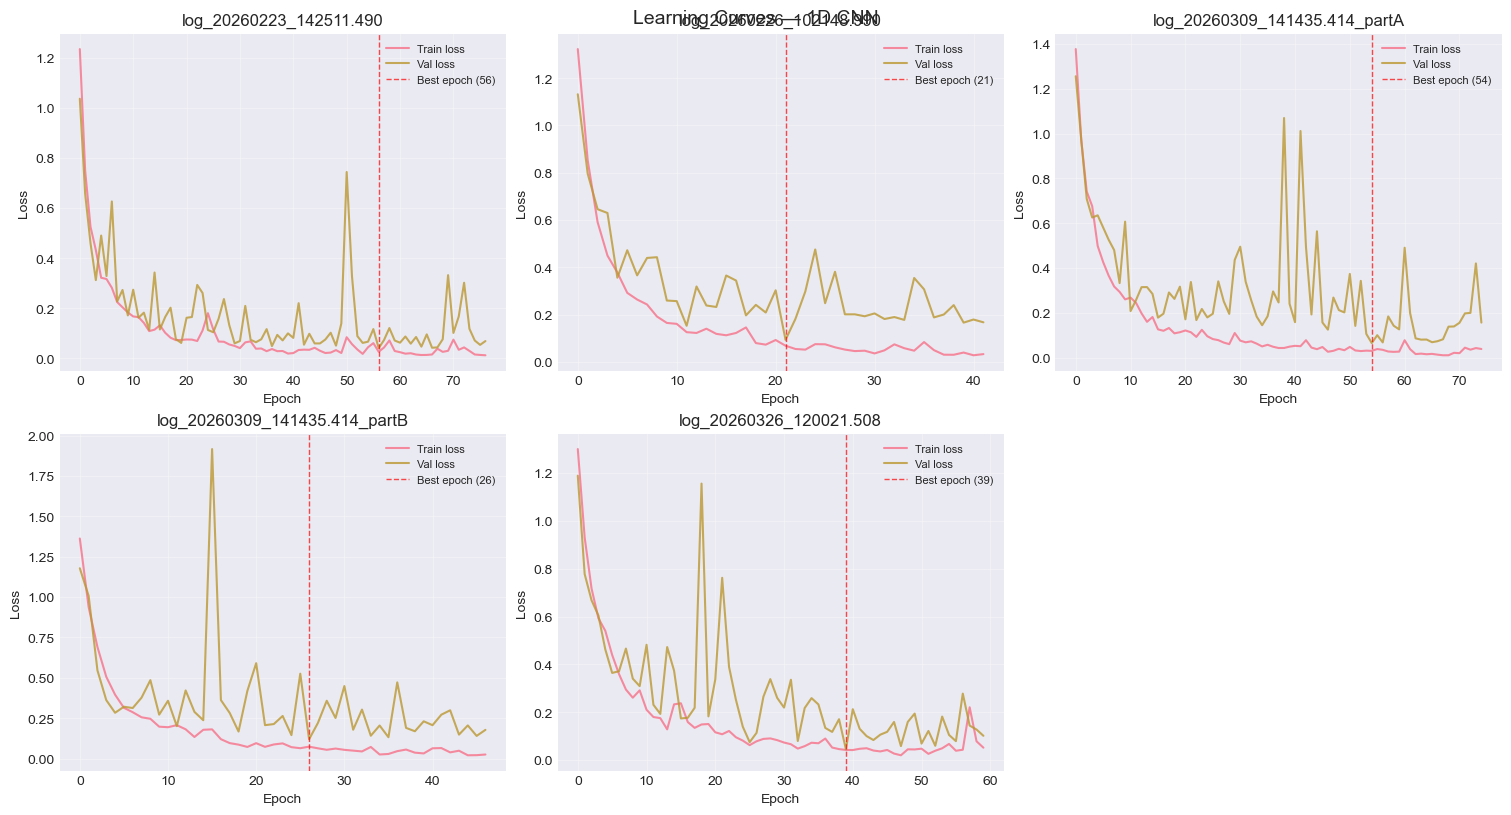

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/cnn_learning_curves.png


In [8]:
n_folds = len(learning_curves_store)
ncols = min(n_folds, 3)
nrows = (n_folds + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), constrained_layout=True)
axes_flat = np.array(axes).flatten() if n_folds > 1 else [axes]

for idx, curve_data in enumerate(learning_curves_store):
    ax = axes_flat[idx]
    test_run    = curve_data["test_run"]
    train_loss  = curve_data["train_loss"]
    val_loss    = curve_data["val_loss"]
    best_epoch  = curve_data["best_epoch"]

    epochs = range(len(train_loss))
    ax.plot(epochs, train_loss, label="Train loss", linewidth=1.5, alpha=0.8)
    ax.plot(epochs, val_loss,   label="Val loss",   linewidth=1.5, alpha=0.8)
    ax.axvline(
        best_epoch, color="red", linestyle="--", linewidth=1, alpha=0.7,
        label=f"Best epoch ({best_epoch})",
    )
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(test_run)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for idx in range(n_folds, len(axes_flat)):
    axes_flat[idx].axis("off")

fig.suptitle("Learning Curves — 1D CNN", fontsize=14, y=1.00)
lc_path = REPORTS_DIR / "cnn_learning_curves.png"
fig.savefig(lc_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {lc_path}")

## Cell 8: Confusion Matrices

/Users/pratyush/miniforge3/envs/ricbot/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9889 (\N{HIGH VOLTAGE SIGN}) missing from font(s) Arial.
  fig.canvas.draw()
/var/folders/wh/6d7zf7cx3632z8j44tx9fqxr0000gn/T/ipykernel_68063/2908487340.py:42: UserWarning: Glyph 9889 (\N{HIGH VOLTAGE SIGN}) missing from font(s) Arial.
  fig.savefig(per_fold_path, dpi=150, bbox_inches="tight")
/Users/pratyush/miniforge3/envs/ricbot/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9889 (\N{HIGH VOLTAGE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


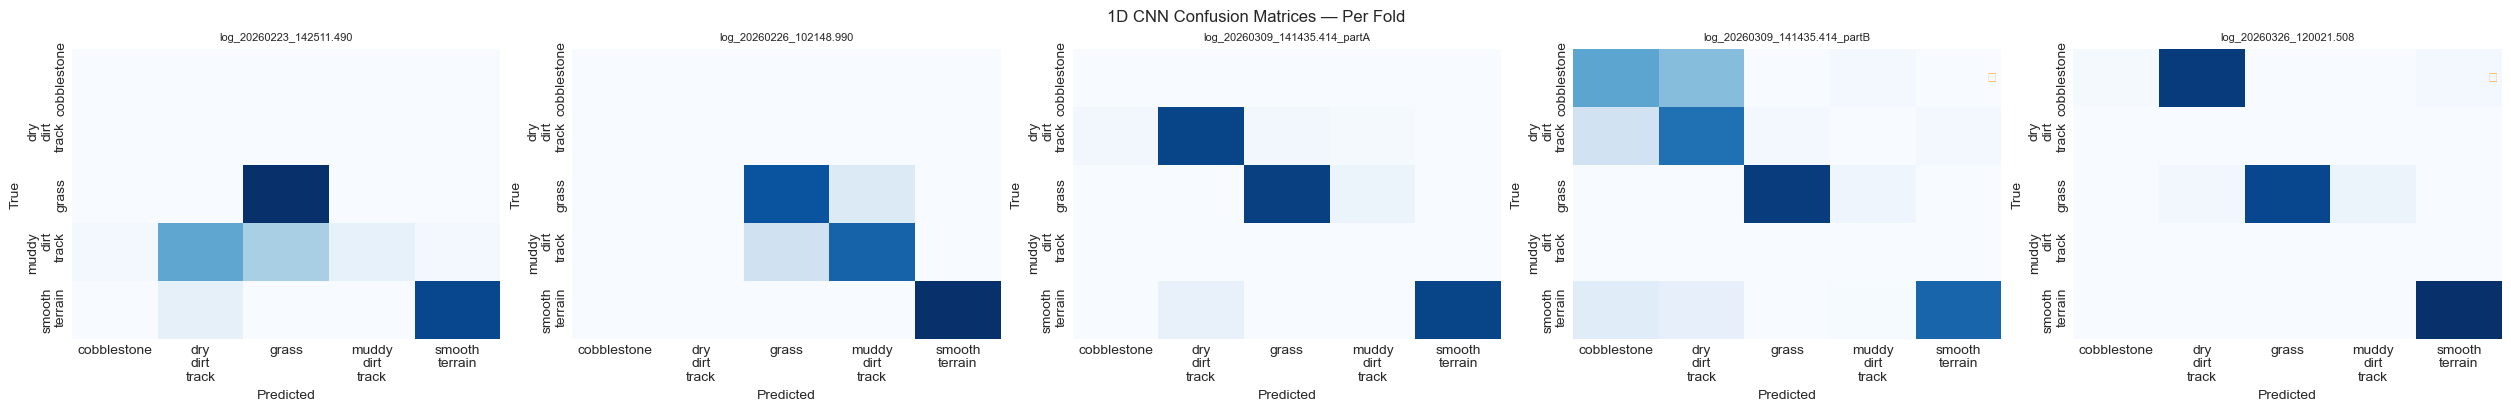

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/cnn_confusion_matrix_per_fold.png


/var/folders/wh/6d7zf7cx3632z8j44tx9fqxr0000gn/T/ipykernel_68063/2908487340.py:83: UserWarning: Glyph 9889 (\N{HIGH VOLTAGE SIGN}) missing from font(s) Arial.
  fig_agg.savefig(agg_path, dpi=150, bbox_inches="tight")
/Users/pratyush/miniforge3/envs/ricbot/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9889 (\N{HIGH VOLTAGE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


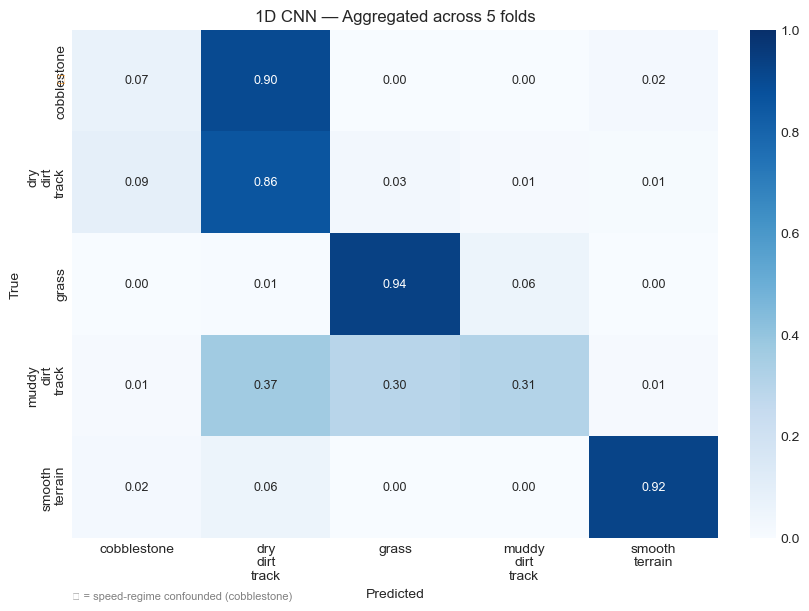

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/cnn_confusion_matrix_aggregated.png


In [9]:
# ============================================================================
# PER-FOLD CONFUSION MATRICES
# ============================================================================
fig, axes = plt.subplots(1, len(run_ids), figsize=(5 * len(run_ids), 4), constrained_layout=True)
if len(run_ids) == 1:
    axes = [axes]

for idx, test_run in enumerate(run_ids):
    ax  = axes[idx]
    rec = next((r for r in confusion_records if r["test_run"] == test_run), None)
    if rec is None:
        ax.axis("off")
        ax.set_title(f"{test_run} (missing)")
        continue

    cm_raw  = confusion_matrix(rec["y_true"], rec["y_pred"], labels=LABEL_ORDER)
    cm_norm = row_normalize(cm_raw)

    short_labels = [lbl.replace("_", "\n") for lbl in LABEL_ORDER]

    sns.heatmap(
        cm_norm, ax=ax, cmap="Blues", vmin=0, vmax=1,
        xticklabels=short_labels, yticklabels=short_labels,
        cbar=False, annot=False,
    )

    # Mark confounded classes
    for conf_cls in KNOWN_CONFOUNDED.get(test_run, {}):
        if conf_cls in LABEL_ORDER:
            c_idx = LABEL_ORDER.index(conf_cls)
            ax.text(
                len(LABEL_ORDER) - 0.05, c_idx + 0.5, "\u26a1",
                ha="right", va="center", fontsize=10, color="darkorange",
            )

    ax.set_title(test_run, fontsize=8)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

fig.suptitle("1D CNN Confusion Matrices — Per Fold", fontsize=12)
per_fold_path = REPORTS_DIR / "cnn_confusion_matrix_per_fold.png"
fig.savefig(per_fold_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {per_fold_path}")

# ============================================================================
# AGGREGATED CONFUSION MATRIX
# ============================================================================
agg_raw = np.zeros((len(LABEL_ORDER), len(LABEL_ORDER)), dtype=int)
for rec in confusion_records:
    agg_raw += confusion_matrix(rec["y_true"], rec["y_pred"], labels=LABEL_ORDER)

agg_norm = row_normalize(agg_raw)

fig_agg, ax_agg = plt.subplots(figsize=(8, 6), constrained_layout=True)
short_labels = [lbl.replace("_", "\n") for lbl in LABEL_ORDER]
sns.heatmap(
    agg_norm, ax=ax_agg, cmap="Blues", vmin=0, vmax=1,
    xticklabels=short_labels, yticklabels=short_labels,
    cbar=True, annot=True, fmt=".2f", annot_kws={"size": 9},
)

all_confounded_classes = set()
for fold_confounds in KNOWN_CONFOUNDED.values():
    all_confounded_classes.update(fold_confounds.keys())

for row_idx, cls_name in enumerate(LABEL_ORDER):
    if cls_name in all_confounded_classes:
        ax_agg.text(
            -0.05, row_idx + 0.5, "\u26a1",
            ha="right", va="center", fontsize=10, color="darkorange",
        )

ax_agg.text(
    0, -0.12, "\u26a1 = speed-regime confounded (cobblestone)",
    transform=ax_agg.transAxes, fontsize=8, color="gray",
)
ax_agg.set_title(f"1D CNN — Aggregated across {len(run_ids)} folds")
ax_agg.set_xlabel("Predicted")
ax_agg.set_ylabel("True")

agg_path = REPORTS_DIR / "cnn_confusion_matrix_aggregated.png"
fig_agg.savefig(agg_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {agg_path}")

## Cell 9: Per-Class Metrics

In [10]:
per_class_df = pd.DataFrame(per_class_rows)

all_confounded_classes = set()
for fold_confounds in KNOWN_CONFOUNDED.values():
    all_confounded_classes.update(fold_confounds.keys())

rows = []
for cls_name in LABEL_ORDER:
    cls_sub   = per_class_df[per_class_df["class"] == cls_name]
    f1_vals   = cls_sub["f1"].dropna()
    folds_eval = int(f1_vals.shape[0])

    def fmt_mean_std(series):
        vals = series.dropna()
        return "NaN" if vals.empty else f"{vals.mean():.3f} ± {vals.std(ddof=0):.3f}"

    warn     = "WARN" if folds_eval < len(run_ids) else ""
    confound = "\u26a1 speed" if cls_name in all_confounded_classes else ""

    rows.append({
        "Class":      cls_name,
        "Precision":  fmt_mean_std(cls_sub["precision"]),
        "Recall":     fmt_mean_std(cls_sub["recall"]),
        "F1":         fmt_mean_std(cls_sub["f1"]),
        "F1 median":  float(f1_vals.median()) if not f1_vals.empty else np.nan,
        "F1 min":     float(f1_vals.min())    if not f1_vals.empty else np.nan,
        "F1 max":     float(f1_vals.max())    if not f1_vals.empty else np.nan,
        "Folds":      f"{folds_eval}/{len(run_ids)}",
        "Flag":       warn,
        "Confound":   confound,
        # Numeric export columns
        "precision_mean": cls_sub["precision"].mean(skipna=True),
        "precision_std":  cls_sub["precision"].std(ddof=0, skipna=True),
        "recall_mean":    cls_sub["recall"].mean(skipna=True),
        "recall_std":     cls_sub["recall"].std(ddof=0, skipna=True),
        "f1_mean":        cls_sub["f1"].mean(skipna=True),
        "f1_std":         cls_sub["f1"].std(ddof=0, skipna=True),
        "f1_median":      float(f1_vals.median()) if not f1_vals.empty else np.nan,
        "f1_min":         float(f1_vals.min())    if not f1_vals.empty else np.nan,
        "f1_max":         float(f1_vals.max())    if not f1_vals.empty else np.nan,
        "folds_evaluated": folds_eval,
    })

pretty_table = pd.DataFrame(rows)[[
    "Class", "Precision", "Recall", "F1", "F1 median", "F1 min", "F1 max",
    "Folds", "Flag", "Confound",
]]
print(f"\nPer-class metrics for 1D CNN:")
print(pretty_table.to_string(index=False))
print("\nNOTE: \u26a1 = cobblestone speed confound.")

export_df = pd.DataFrame(rows)[[
    "Class", "precision_mean", "precision_std", "recall_mean", "recall_std",
    "f1_mean", "f1_std", "f1_median", "f1_min", "f1_max", "folds_evaluated", "Flag", "Confound",
]]
per_class_out = RESULTS_DIR / "cnn_per_class_metrics.csv"
export_df.to_csv(per_class_out, index=False)
print(f"\nSaved: {per_class_out}")


Per-class metrics for 1D CNN:
           Class     Precision        Recall            F1  F1 median   F1 min   F1 max Folds Flag Confound
     cobblestone 0.619 ± 0.381 0.280 ± 0.261 0.184 ± 0.147   0.183808 0.037037 0.330579   2/5 WARN  ⚡ speed
  dry_dirt_track 0.921 ± 0.039 0.838 ± 0.086 0.877 ± 0.065   0.876750 0.811715 0.941785   2/5 WARN         
           grass 0.812 ± 0.203 0.934 ± 0.045 0.849 ± 0.131   0.888889 0.604651 0.963265   5/5              
muddy_dirt_track 0.930 ± 0.070 0.443 ± 0.362 0.490 ± 0.341   0.490497 0.149533 0.831461   2/5 WARN         
  smooth_terrain 0.974 ± 0.027 0.926 ± 0.076 0.948 ± 0.049   0.961440 0.857143 1.000000   5/5              

NOTE: ⚡ = cobblestone speed confound.

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/results/cnn/cnn_per_class_metrics.csv


## Cell 10: Comparison with Baseline and MLP

In [11]:
cnn_macro_f1_mean = summary_s["macro_f1_mean"]
cnn_macro_f1_std  = summary_s["macro_f1_std"]
cnn_robustness    = summary_s["robustness_score"]

comparison_rows = []

# Load MLP results if available
mlp_summary_path = PROJECT_ROOT / "results" / "mlp_metrics_summary.csv"
if mlp_summary_path.exists():
    mlp_df = pd.read_csv(mlp_summary_path)
    # Use the feature set with highest macro_f1_mean
    if not mlp_df.empty:
        mlp_best = mlp_df.sort_values("macro_f1_mean", ascending=False).iloc[0]
        comparison_rows.append({
            "Model":         f"MLP ({mlp_best.get('feature_set', 'best')})",
            "Macro F1 mean": f"{mlp_best['macro_f1_mean']:.3f}",
            "Macro F1 std":  f"{mlp_best['macro_f1_std']:.3f}",
            "Robustness":    f"{mlp_best['robustness_score']:.3f}",
            "Worst fold F1": f"{mlp_best['worst_fold_macro_f1']:.3f}",
        })
else:
    warnings.warn(f"MLP summary not found at {mlp_summary_path}. Skipping MLP comparison.")

# Load baseline results if available
baseline_summary_path = PROJECT_ROOT / "results" / "baseline_metrics_summary.csv"
if baseline_summary_path.exists():
    bl_df = pd.read_csv(baseline_summary_path)
    if not bl_df.empty:
        bl_best = bl_df.sort_values("macro_f1_mean", ascending=False).iloc[0]
        comparison_rows.append({
            "Model":         f"Baseline best ({bl_best.get('model', '?')}, {bl_best.get('feature_set', '?')})",
            "Macro F1 mean": f"{bl_best['macro_f1_mean']:.3f}",
            "Macro F1 std":  f"{bl_best['macro_f1_std']:.3f}",
            "Robustness":    f"{bl_best['robustness_score']:.3f}",
            "Worst fold F1": f"{bl_best['worst_fold_macro_f1']:.3f}",
        })
else:
    warnings.warn(f"Baseline summary not found at {baseline_summary_path}. Skipping baseline comparison.")

comparison_rows.append({
    "Model":         "1D CNN (raw signals)",
    "Macro F1 mean": f"{cnn_macro_f1_mean:.3f}",
    "Macro F1 std":  f"{cnn_macro_f1_std:.3f}",
    "Robustness":    f"{cnn_robustness:.3f}",
    "Worst fold F1": f"{summary_s['worst_fold_macro_f1']:.3f}",
})

if comparison_rows:
    print("\n" + "=" * 80)
    print("MODEL COMPARISON")
    print("=" * 80)
    print(pd.DataFrame(comparison_rows).to_string(index=False))
else:
    print("No comparison data available.")


MODEL COMPARISON
                                     Model Macro F1 mean Macro F1 std Robustness Worst fold F1
                              MLP (top_mi)         0.766        0.119      0.706         0.599
Baseline best (LogisticRegression, top_mi)         0.775        0.122      0.714         0.626
                      1D CNN (raw signals)         0.757        0.137      0.688         0.567


## Cell 11: Thesis Summary

In [12]:
print("\n" + "=" * 100)
print("THESIS SUMMARY: 1D CNN for Terrain Classification")
print("=" * 100)
print(f"""
EXPERIMENTAL SETUP:
  Dataset: Dataset A (5 terrain classes, raw IMU signals)
  Input:   {N_CHANNELS} channels × {WINDOW_SIZE} timesteps per window  ({WINDOW_SIZE / 100:.1f} s at 100 Hz)
  Channels: {SIGNAL_COLS}  (gy/yaw excluded — encodes turning, not terrain)
  Split Strategy: Leave-One-Run-Out Cross-Validation (LORO-CV)
  Folds: {len(run_ids)} runs (run 3 split temporally into partA + partB)
  Total Windows: {len(win_df):,}
  No feature engineering — CNN learns representations directly from raw signals.

MODEL ARCHITECTURE:
  Type: 1D Convolutional Neural Network (PyTorch)
  Backbone:
    Block 1: Conv1d(5→32,  k=7, p=3) → BN → ReLU → MaxPool(2)  [200→100]
    Block 2: Conv1d(32→64, k=5, p=2) → BN → ReLU → MaxPool(2)  [100→50]
    Block 3: Conv1d(64→128,k=3, p=1) → BN → ReLU → MaxPool(2)  [ 50→25]
  Head:     AdaptiveAvgPool(1) → FC(128→64) → ReLU → Dropout({DROPOUT_RATE}) → FC(64→C)

TRAINING CONFIGURATION:
  Optimizer: Adam (lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})
  Batch size: {BATCH_SIZE}
  Max epochs: {MAX_EPOCHS}
  Early stopping patience: {EARLY_STOPPING_PATIENCE}
  Validation split: {VAL_SPLIT * 100:.1f}% (stratified, inside training fold)

  ✓ Validation split carved from training fold ONLY
  ✓ Never overlaps with held-out test run
  ✓ LabelEncoder fitted on training labels only (no leakage)
  ✓ Class-weighted CrossEntropyLoss (inverse frequency, per fold)

RESULTS:
  Macro F1 (mean ± std): {summary_s["macro_f1_mean"]:.3f} ± {summary_s["macro_f1_std"]:.3f}
  Macro F1 (median):     {summary_s["macro_f1_median"]:.3f}
  Accuracy (mean):       {summary_s["accuracy_mean"]:.3f} ± {summary_s["accuracy_std"]:.3f}
  Robustness score:      {summary_s["robustness_score"]:.3f}
  Worst fold macro F1:   {summary_s["worst_fold_macro_f1"]:.3f}
  Evaluable folds:       {int(summary_s["evaluable_folds"])}/{len(run_ids)}

OUTPUTS SAVED:
  Results:
    - {RESULTS_DIR / "cnn_metrics_per_fold.csv"}
    - {RESULTS_DIR / "cnn_metrics_summary.csv"}
    - {RESULTS_DIR / "cnn_per_class_metrics.csv"}
  Visualizations:
    - {REPORTS_DIR / "cnn_learning_curves.png"}
    - {REPORTS_DIR / "cnn_confusion_matrix_per_fold.png"}
    - {REPORTS_DIR / "cnn_confusion_matrix_aggregated.png"}
""")
print("=" * 100)
print("Notebook complete.")
print("=" * 100)


THESIS SUMMARY: 1D CNN for Terrain Classification

EXPERIMENTAL SETUP:
  Dataset: Dataset A (5 terrain classes, raw IMU signals)
  Input:   5 channels × 200 timesteps per window  (2.0 s at 100 Hz)
  Channels: ['ax', 'ay', 'az', 'gx', 'gz']  (gy/yaw excluded — encodes turning, not terrain)
  Split Strategy: Leave-One-Run-Out Cross-Validation (LORO-CV)
  Folds: 5 runs (run 3 split temporally into partA + partB)
  Total Windows: 2,346
  No feature engineering — CNN learns representations directly from raw signals.

MODEL ARCHITECTURE:
  Type: 1D Convolutional Neural Network (PyTorch)
  Backbone:
    Block 1: Conv1d(5→32,  k=7, p=3) → BN → ReLU → MaxPool(2)  [200→100]
    Block 2: Conv1d(32→64, k=5, p=2) → BN → ReLU → MaxPool(2)  [100→50]
    Block 3: Conv1d(64→128,k=3, p=1) → BN → ReLU → MaxPool(2)  [ 50→25]
  Head:     AdaptiveAvgPool(1) → FC(128→64) → ReLU → Dropout(0.3) → FC(64→C)

TRAINING CONFIGURATION:
  Optimizer: Adam (lr=0.001, weight_decay=0.0001)
  Batch size: 64
  Max epochs: